In [12]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr

import sys

from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from pyS3M import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

/tmp/ipykernel_3930145/474819105.py:31: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [4]:
# data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = "../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [5]:
folder = '/home/jsb92/Downloads/previously provided PRISM 20 color spectra in csv/241114_core_20_for_Harrison'

In [6]:
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])


In [8]:
spectral_files = H_F.file_search(folder, '.csv', '')

In [13]:
data = pd.read_csv(spectral_files[0])

,wvl,emission
0,430,0.000813
1,431,0.000846
2,432,0.000895
3,433,0.001108
4,434,0.001384
...,...,...
466,896,0.033420
467,897,0.032526
468,898,0.031685
469,899,0.030938


In [10]:
nps_rgb = np.zeros([3, len(spectral_files)])

In [19]:
data_em.values

array([  6.52824389e-06,   6.79220118e-06,   7.18974844e-06,
         8.89856007e-06,   1.11112681e-05,   1.43900347e-05,
         1.80061141e-05,   2.17689445e-05,   2.41688633e-05,
         2.72122634e-05,   3.20445962e-05,   4.15871415e-05,
         5.90985942e-05,   8.50005638e-05,   1.22397486e-04,
         1.76740579e-04,   2.53343506e-04,   3.59620671e-04,
         5.06996724e-04,   7.02567422e-04,   9.65402057e-04,
         1.31357924e-03,   1.73020510e-03,   2.18907931e-03,
         2.58600438e-03,   2.83310738e-03,   2.85046936e-03,
         2.68684329e-03,   2.38573234e-03,   2.04492970e-03,
         1.72189019e-03,   1.43137672e-03,   1.19756893e-03,
         1.00825560e-03,   8.73266759e-04,   7.80289231e-04,
         7.37139947e-04,   7.35515368e-04,   7.75281566e-04,
         8.37980400e-04,   9.15257245e-04,   9.87579765e-04,
         1.04291502e-03,   1.08050258e-03,   1.09347548e-03,
         1.09462813e-03,   1.08463204e-03,   1.06614943e-03,
         1.03438897e-03,

In [22]:
for i, file in enumerate(spectral_files):
    data = pd.read_csv(file)
    data_wl = data['wvl'].values
    data_em = data['emission'].values/np.trapz(data['emission'].values, x=data_wl)
    B_interp = np.interp(x=data_wl, fp=B, xp=wavelength)
    G_interp = np.interp(x=data_wl, fp=G, xp=wavelength)
    R_interp = np.interp(x=data_wl, fp=R, xp=wavelength)
    pixel_QYs_interp = np.vstack([B_interp, G_interp, R_interp])
    _, nps_rgb[:, i] = S_F.get_pixel_fractions_rawspectra(spectra=data_em, wavelength=data_wl, pixel_QYs=pixel_QYs_interp)

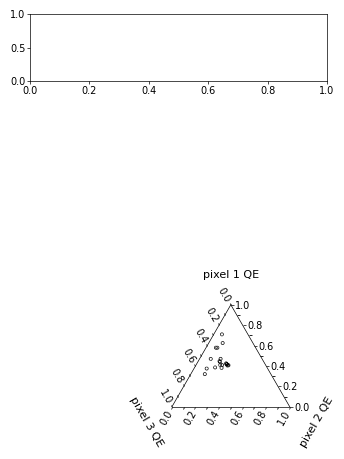

In [31]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[0.1, 0.9])

axs = plotter.ternary_scatter_plot(fig=fig, axs=axs, B=nps_rgb[0, :], G=nps_rgb[1, :], R=nps_rgb[2, :], colours='black', s=5)


In [3]:
image_size = 20
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [4]:
n_photon_space = np.logspace(np.log10(500), np.log10(100000), 100)
n_bootstrap = 50000
background_photons = 5.0
pixel_size = 69
NA = 1.49

In [5]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [6]:
spectra = pl.read_csv("../Spectra/Nanoparticles/CL_spectra.csv")

dyes = spectra.columns[1:]

In [7]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
nilered_filter = "semrock-ff01-650-200-25"
shortpass_filter = "semrock-bsp01-785r"
filters = []

In [10]:
save_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence"
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [ ]:
for dye in dyes:
    dyename = "simulated_" + dye
    single_dye_spectrum = np.interp(wavelength, spectra["wv"], np.abs(spectra[dye]))
    single_dye_spectrum = single_dye_spectrum / np.sum(single_dye_spectrum)
    print(
        "Analysing dye {}".format(dyename),
        end="\r",
        flush=True,
    )
    MSF.test_fit_method(
        dyename,
        filters,
        wavelength,
        camera_parameters,
        save_folder,
        n_photon_space,
        smoothing_function=smoothing_function,
        starting_flag="CL_",
        n_bootstrap=n_bootstrap,
        background_photons=background_photons,
        NA=NA,
        pixel_size=pixel_size,
        cpu_fraction=1,
        single_dye_spectrum=single_dye_spectrum,
        save_raw_results=True,
    )

In [ ]:
all_files = np.sort(os.listdir(save_folder))

In [ ]:
Overall_XR = xr.DataArray(
    data=np.zeros([len(n_photon_space), n_bootstrap, len(dyes), 3]),
    coords=[n_photon_space, np.arange(n_bootstrap) + 1, dyes, ["B", "G", "R"]],
    dims=["Photons", "Bootstrap_Repeat", "Dye", "Colour"],
)

In [ ]:
for i, dye in enumerate(dyes):
    files = np.sort(
        [
            os.path.join(save_folder, x)
            for x in all_files
            if dye in x and "rawresults" in x and "#" not in x
        ]
    )
    for j, n_photon in enumerate(n_photon_space):
        file = np.array(
            [
                x
                for x in files
                if str(np.around(n_photon, 2)).replace(".", "p").zfill(10) in x
            ]
        )[0]
        data = pl.read_csv(file)
        for k, colour in enumerate(np.array(["A_B", "A_G", "A_R"])):
            Overall_XR[j, :, i, k] = data[colour].to_numpy()

In [ ]:
Overall_XR.to_netcdf(os.path.join(save_folder, "Simulated_CL_database.nc"))

In [63]:
Overall_XR = xr.load_dataarray(os.path.join(save_folder, "Simulated_CL_database.nc"))

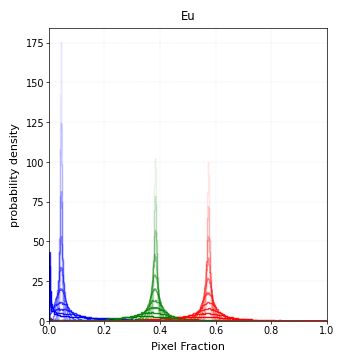

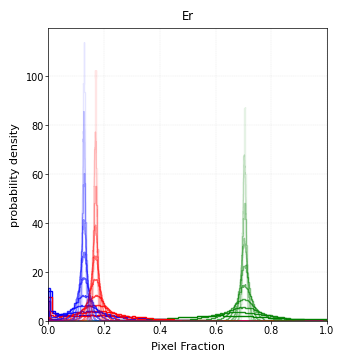

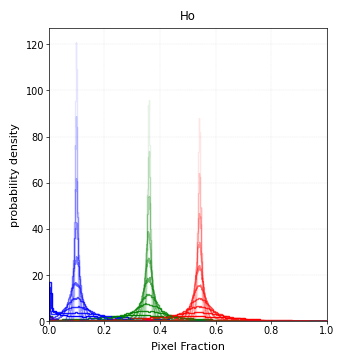

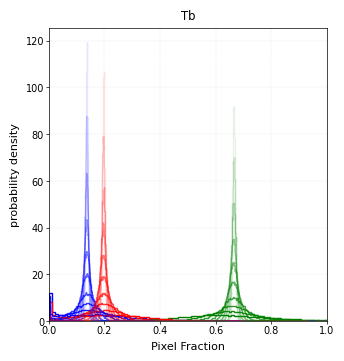

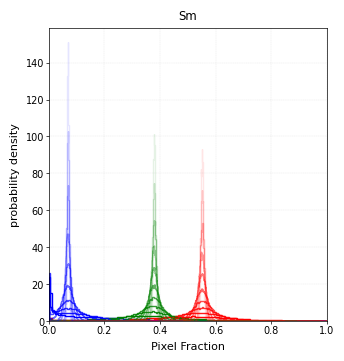

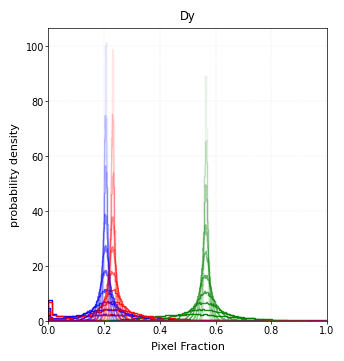

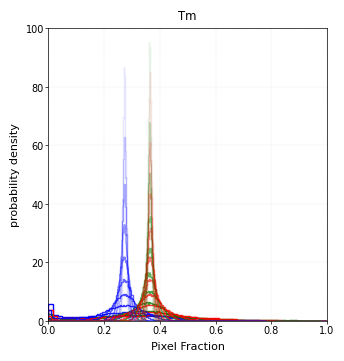

In [16]:
alpha = np.linspace(1, 0.1, 10)
for i, dye in enumerate(Overall_XR.Dye):
    fig, axs = plotter.one_column_plot()
    for av, j in enumerate(np.arange(len(Overall_XR.Photons))[::10]):
        pval = str(int(np.around(Overall_XR.Photons[j])))

        B = Overall_XR[j, :, i, 0]
        G = Overall_XR[j, :, i, 1]
        R = Overall_XR[j, :, i, 2]
        axs = plotter.histogram_plot(
            axs=axs,
            data=B,
            bins=np.histogram_bin_edges(B, "fd"),
            histcolor="blue",
            alpha=alpha[av],
            histtype="step",
        )
        axs = plotter.histogram_plot(
            axs=axs,
            data=G,
            bins=np.histogram_bin_edges(G, "fd"),
            histcolor="green",
            alpha=alpha[av],
            histtype="step",
        )
        axs = plotter.histogram_plot(
            axs=axs,
            data=R,
            bins=np.histogram_bin_edges(R, "fd"),
            histcolor="red",
            alpha=alpha[av],
            xaxislabel="Pixel Fraction",
            histtype="step",
        )

    axs.set_xlim([0, 1])
    axs.set_title(str(dye.values))
    plt.savefig(
        os.path.join(save_folder, "Histogram_Plots", str(dye.values) + ".svg"),
        dpi=600,
        format="svg",
    )
    plt.show()

In [66]:
import sklearn
from sklearn import mixture, metrics

In [68]:
p = 0
d = 0
B = Overall_XR[p, :, d, 0]
G = Overall_XR[p, :, d, 1]
R = Overall_XR[p, :, d, 2]
X = np.vstack([B, G, R]).T
means_init = np.array([[np.nanmean(B), np.nanmean(G), np.nanmean(R)]])
gmm = mixture.GaussianMixture(
    n_components=1, covariance_type="full", means_init=means_init
).fit(X)

In [81]:
import numpy as np
from scipy.linalg import solve, det
from scipy.stats import norm


def gaussian_confusion_matrix(mu1, cov1, mu2, cov2):
    """
    Compute the analytical confusion matrix for two multivariate Gaussian distributions.

    Parameters:
        mu1 : array_like, shape (d,)
            Mean vector of the first distribution (Class 0).
        cov1 : array_like, shape (d, d)
            Covariance matrix of the first distribution.
        mu2 : array_like, shape (d,)
            Mean vector of the second distribution (Class 1).
        cov2 : array_like, shape (d, d)
            Covariance matrix of the second distribution.

    Returns:
        np.ndarray, shape (2, 2): Confusion matrix [TP, FP; FN, TN] as rates.
    """
    # Difference in means
    delta = mu1 - mu2

    # Average covariance matrix
    sigma = 0.5 * (cov1 + cov2)

    # Solve for sigma^{-1} * delta
    sigma_inv_delta = solve(sigma, delta, assume_a="pos")

    # Mahalanobis distance squared
    d_sq = delta @ sigma_inv_delta

    # Bhattacharyya distance term (for covariance difference adjustment)
    det_sigma = det(sigma)
    det_cov1 = det(cov1)
    det_cov2 = det(cov2)
    ln_term = 0.5 * np.log(det_sigma / np.sqrt(det_cov1 * det_cov2))

    # Adjusted threshold for classification boundary
    threshold = 2 * ln_term

    # Standard deviation of the discriminant function
    std_dev = np.sqrt(d_sq)

    # Calculate probabilities using CDF
    TP = norm.cdf((0.5 * d_sq - threshold) / std_dev)  # P(Class 0 -> Class 0)
    FN = 1 - TP  # P(Class 0 -> Class 1)
    TN = norm.cdf((0.5 * d_sq + threshold) / std_dev)  # P(Class 1 -> Class 1)
    FP = 1 - TN  # P(Class 1 -> Class 0)

    conf_matrix = np.array([[TP, FP], [FN, TN]])
    return conf_matrix / np.sum(conf_matrix)

Confusion Matrix (TP, FP; FN, TN):
[[  4.99507667e-01   4.58661420e-04]
 [  4.92332845e-04   4.99541339e-01]]


In [84]:
import itertools

dyes = Overall_XR.Dye.values
for L in range(len(dyes) + 1):
    for subset in itertools.combinations(dyes, L):
        if len(subset) == 2:
            dyeindices = np.squeeze(
                [np.where(Overall_XR.Dye.values == x)[0] for x in subset]
            )
            dye_strings = Overall_XR.Dye.values[dyeindices]
            savestr = "_".join([str(x) for x in dye_strings])
            savename = os.path.join(
                save_folder, "Confusion_Matrices", "Confusion_Matrix_" + savestr + ".nc"
            )
            if not os.path.isfile(savename):
                print(savename)
                confusion_tensor = np.zeros(
                    [len(subset), len(subset), len(Overall_XR.Photons)]
                )
                for p in np.arange(len(Overall_XR.Photons)):
                    mus = np.zeros([len(subset), 3])
                    covariances = np.zeros([len(subset), 3, 3])
                    for subset_val, d in enumerate(dyeindices):
                        B = Overall_XR[p, :, d, 0]
                        G = Overall_XR[p, :, d, 1]
                        R = Overall_XR[p, :, d, 2]
                        X = np.vstack([B, G, R]).T
                        means_init = np.array(
                            [[np.nanmean(B), np.nanmean(G), np.nanmean(R)]]
                        )
                        gmm = mixture.GaussianMixture(
                            n_components=1,
                            covariance_type="full",
                            means_init=means_init,
                        ).fit(X)
                        mus[subset_val, :] = np.squeeze(gmm.means_)
                        covariances[subset_val, :, :] = np.squeeze(gmm.covariances_)

                    confusion_tensor[:, :, p] = gaussian_confusion_matrix(
                        mus[0, :], covariances[0, :, :], mus[1, :], covariances[1, :, :]
                    )
                confusion_xr = xr.DataArray(
                    data=confusion_tensor,
                    coords=[dye_strings, dye_strings, Overall_XR.Photons.values],
                    dims=["Dye1", "Dye2", "Photon"],
                )
                savestr = "_".join([str(x) for x in dye_strings])
                confusion_xr.to_netcdf(savename)

/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence/Confusion_Matrices/Confusion_Matrix_Eu_Er.nc
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence/Confusion_Matrices/Confusion_Matrix_Eu_Ho.nc
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence/Confusion_Matrices/Confusion_Matrix_Eu_Tb.nc
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence/Confusion_Matrices/Confusion_Matrix_Eu_Sm.nc
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence/Confusion_Matrices/Confusion_Matrix_Eu_Dy.nc
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence/Confusion_Matrices/Confusion_Matrix_Eu_Tm.nc
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence/Confusion_Matrices/Confusion_Matrix_Er_Ho.nc
/home/jbeckwith/Documents/pCloud/Chemistr

In [85]:
confusion_files = np.sort(os.listdir(os.path.join(save_folder, "Confusion_Matrices")))
confusion_files = np.sort(
    [
        os.path.join(save_folder, "Confusion_Matrices", x)
        for x in confusion_files
        if ".nc" in x
    ]
)

In [91]:
def error_calculator(data):
    error_matrix = np.zeros_like(data.Photon.values)
    for p in np.arange(len(data.Photon.values)):
        p_data = data[:, :, p].values
        dia = np.diag_indices(p_data.shape[0])  # indices of diagonal elements
        dia_sum = np.nansum(p_data[dia])  # sum of diagonal elements
        off_dia_sum = (
            np.nansum(p_data) - dia_sum
        )  # subtract the diagonal sum from total array sum
        error_matrix[p] = 1 - np.abs(dia_sum - off_dia_sum)
    return error_matrix

In [115]:
confusion_files[0]

'/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_CathodoLuminescence/Confusion_Matrices/Confusion_Matrix_Dy_Tm.nc'

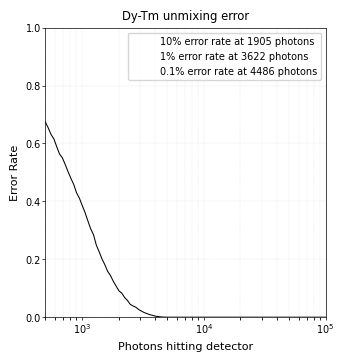

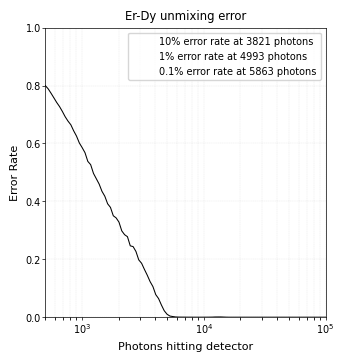

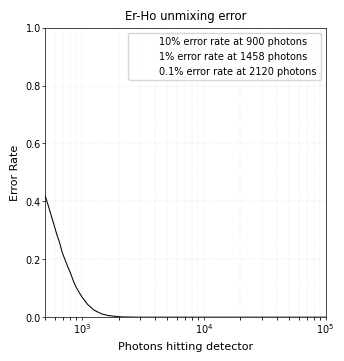

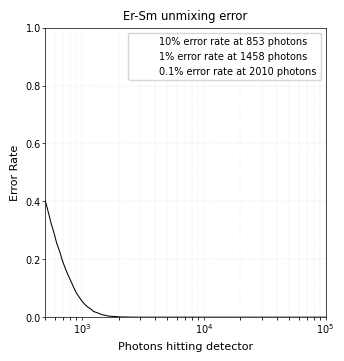

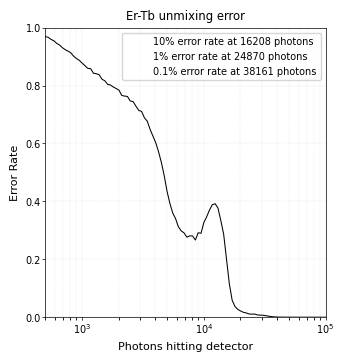

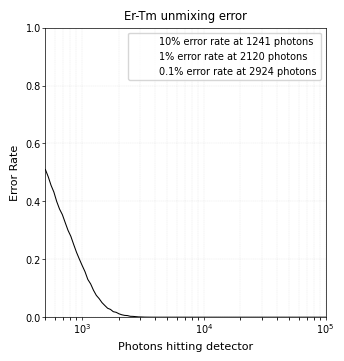

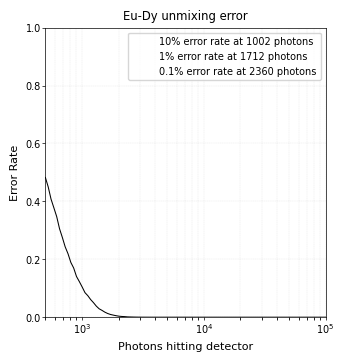

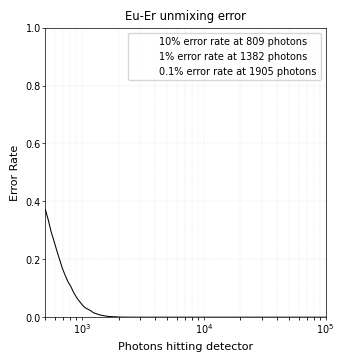

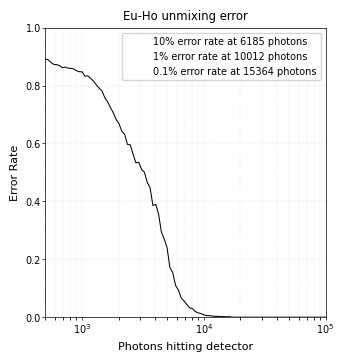

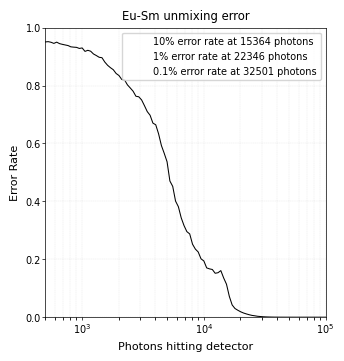

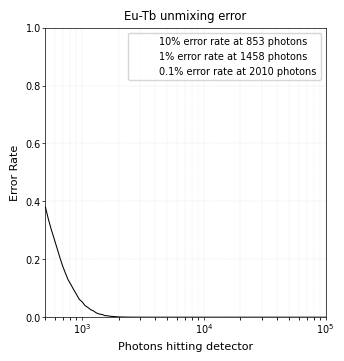

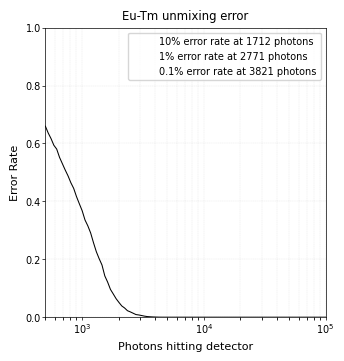

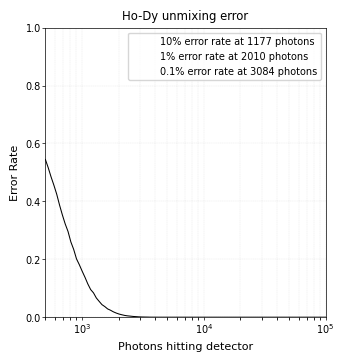

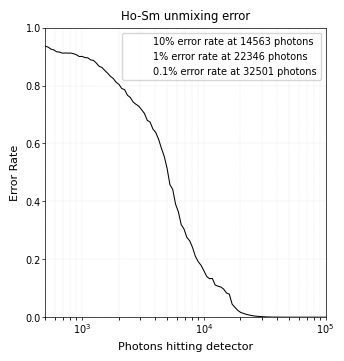

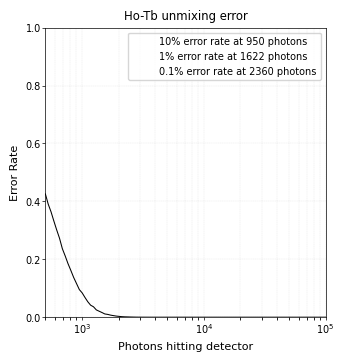

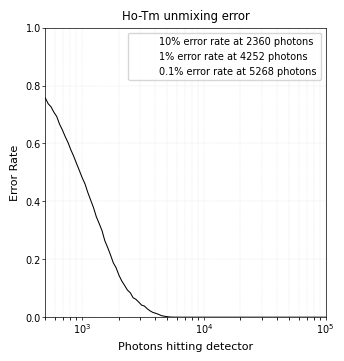

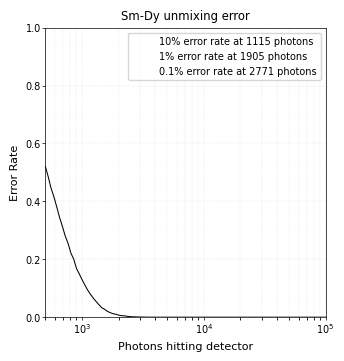

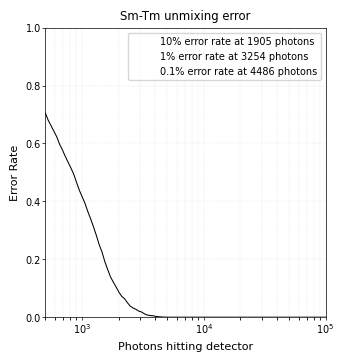

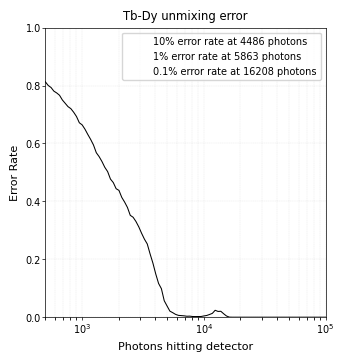

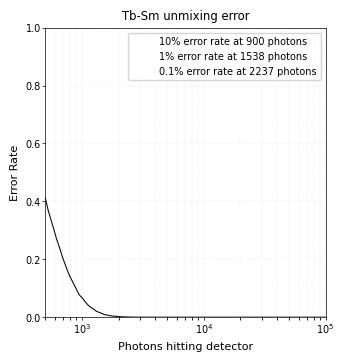

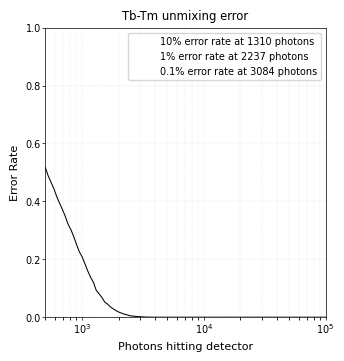

In [117]:
for i in np.arange(len(confusion_files)):
    data = xr.load_dataarray(confusion_files[i])
    error_m = error_calculator(data)
    savestr = confusion_files[i].split(".nc")[0] + "_Plot.svg"
    fig, axs = plotter.one_column_plot()

    axs = plotter.line_plot(
        axs,
        x=data.Photon.values,
        y=error_m,
        xaxislabel="Photons hitting detector",
        yaxislabel="Error Rate",
    )
    error_10perc = int(data.Photon.values[np.argmin(np.abs(error_m - 0.1))])
    error_1perc = int(data.Photon.values[np.argmin(np.abs(error_m - 0.01))])
    error_0p1perc = int(data.Photon.values[np.argmin(np.abs(error_m - 0.001))])

    axs.plot(
        0, 0, alpha=0, label=r"10% error rate at " + str(error_10perc) + " photons"
    )
    axs.plot(0, 0, alpha=0, label=r"1% error rate at " + str(error_1perc) + " photons")
    axs.plot(
        0, 0, alpha=0, label=r"0.1% error rate at " + str(error_0p1perc) + " photons"
    )

    axs.set_xscale("log")
    axs.set_xlim([500, 1e5])
    axs.set_ylim([0, 1])
    axs.legend(loc="best")
    title = ("-").join(list(data.Dye1.values)) + " unmixing error"
    axs.set_title(title)
    plt.savefig(savestr, dpi=600, format="svg")
    plt.show()